# El pitch clock y los pitchers de MLB (2019–2026)

EDA del dataset generado con `python -m pitchclock.build_dataset`. Tres preguntas:

1. **Tiempo**: ¿cuánto se acortaron los juegos y el ritmo entre pitcheos?
2. **Spin rate**: ¿bajó el spin de los pitchers cuando tuvieron menos tiempo?
3. **Lesiones**: ¿aumentaron las estancias en el IL, sobre todo de brazo y codo?

> Análisis descriptivo, **no causal**. La vigilancia de sustancias pegajosas (2021), la temporada corta de 2020 y la tendencia de fondo de más velocidad también influyen. Ver el README.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data/processed')
ps = pd.read_csv(DATA / 'pitcher_season.csv')
lg = pd.read_csv(DATA / 'league_season.csv')
games = pd.read_csv(DATA / 'games.csv')
stints = pd.read_csv(DATA / 'il_stints.csv')

# Estilo: gris = sin reloj, azul = con reloj. Un solo eje por gráfica.
PRE, POST, INK, MUTED, GRID = '#8f8e89', '#2a78d6', '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'font.size': 10,
})
colors = lambda seasons: [POST if s >= 2023 else PRE for s in seasons]

def clock_line(ax):
    ax.axvline(2022.5, color=MUTED, lw=1, ls='--')
    lo, hi = ax.get_ylim()
    ax.text(2022.6, lo + (hi - lo) * 0.04, 'pitch clock →', va='bottom', color=MUTED, fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', pad=1))

def year_bars(ax, s, fmt='{:.0f}', exclude=(2020,)):
    s = s.drop(index=[y for y in exclude if y in s.index])
    bars = ax.bar(s.index, s.values, color=colors(s.index), width=0.65)
    ax.bar_label(bars, labels=[fmt.format(v) for v in s.values], padding=3, color=INK, fontsize=9)
    ax.set_xticks(s.index); ax.set_axisbelow(True); ax.margins(y=0.15)
    return bars

def year_points(ax, s, fmt='{:.0f}'):
    # Para ejes que no empiezan en 0: puntos + línea (las barras exagerarían la diferencia).
    ax.plot(s.index, s.values, color=GRID, lw=2, zorder=1)
    ax.scatter(s.index, s.values, c=colors(s.index), s=60, zorder=2, edgecolor='white', linewidth=1.5)
    for x, v in s.items():
        ax.annotate(fmt.format(v), (x, v), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9)
    ax.set_xticks(s.index); ax.margins(y=0.2)

print(ps.shape, ps.season.min(), ps.season.max())
ps.head()

(6362, 65) 2019 2026


,pitcher_id,name,season,team,throws,role,post_clock,clock_rule,short_season,sticky_enforcement,...,velo_SL_delta,spin_ST_delta,velo_ST_delta,spin_CU_delta,velo_CU_delta,spin_CH_delta,velo_CH_delta,spin_FS_delta,velo_FS_delta,spin_drop_flag
0,282332,CC Sabathia,2019,New York Yankees,L,SP,0,none,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,407845,Fernando Rodney,2019,Washington Nationals,R,RP,0,none,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,424144,Oliver Pérez,2019,Cleveland Indians,L,RP,0,none,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,425794,Adam Wainwright,2019,St. Louis Cardinals,R,SP,0,none,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,425844,Zack Greinke,2019,Houston Astros,R,SP,0,none,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Tiempo
### Duración de juegos de 9 entradas

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


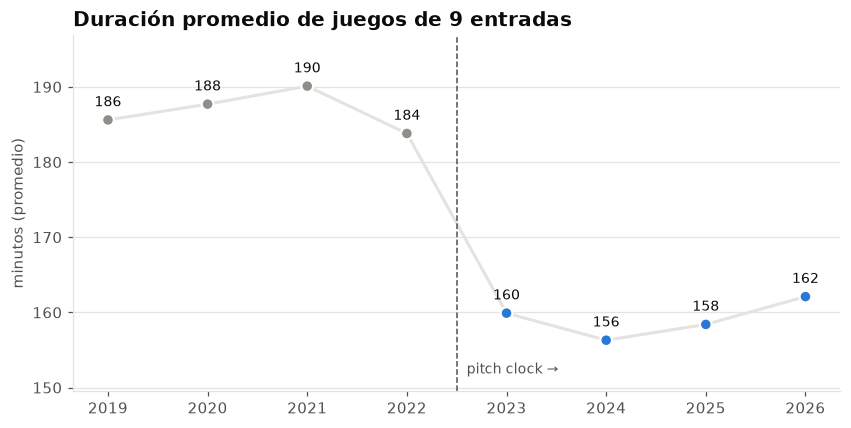

,season,avg_game_min_9inn,median_game_min_9inn
0,2019,185.6,185.0
1,2020,187.7,186.0
2,2021,190.1,189.0
3,2022,183.8,182.0
4,2023,159.9,159.0
5,2024,156.3,155.0
6,2025,158.4,158.0
7,2026,162.1,161.0


In [2]:
fig, ax = plt.subplots()
year_points(ax, lg.set_index('season')['avg_game_min_9inn'])
ax.set_ylabel('minutos (promedio)')
ax.set_title('Duración promedio de juegos de 9 entradas')
clock_line(ax); plt.show()
lg[['season', 'avg_game_min_9inn', 'median_game_min_9inn']]

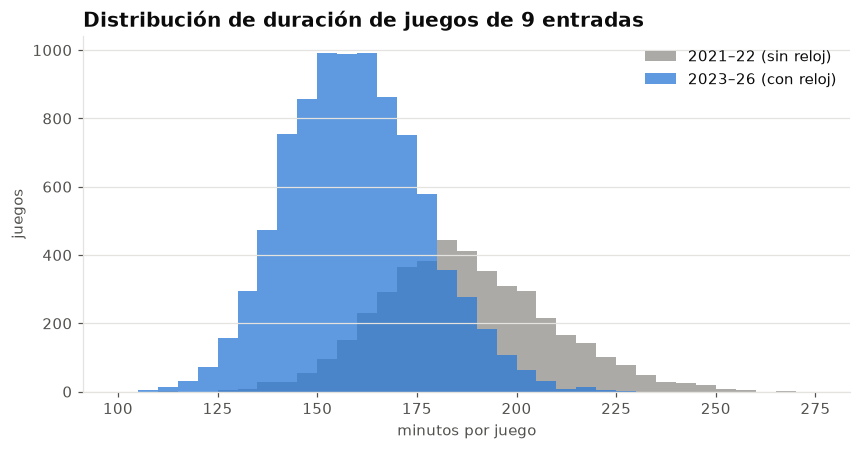

In [3]:
# Distribución por juego: antes vs. con reloj
g9 = games[games.nine_innings]
fig, ax = plt.subplots()
bins = np.arange(100, 280, 5)
ax.hist(g9[g9.season.between(2021, 2022)].duration_min, bins=bins, color=PRE, alpha=.75, label='2021–22 (sin reloj)')
ax.hist(g9[g9.season.between(2023, 2026)].duration_min, bins=bins, color=POST, alpha=.75, label='2023–26 (con reloj)')
ax.set_xlabel('minutos por juego'); ax.set_ylabel('juegos'); ax.legend(frameon=False)
ax.set_title('Distribución de duración de juegos de 9 entradas'); plt.show()

### Ritmo del pitcher (mediana de segundos entre pitcheos, Savant)
Savant mide de lanzamiento a lanzamiento cuando el pitcheo anterior fue *take*, por eso los valores son menores que el reloj oficial.

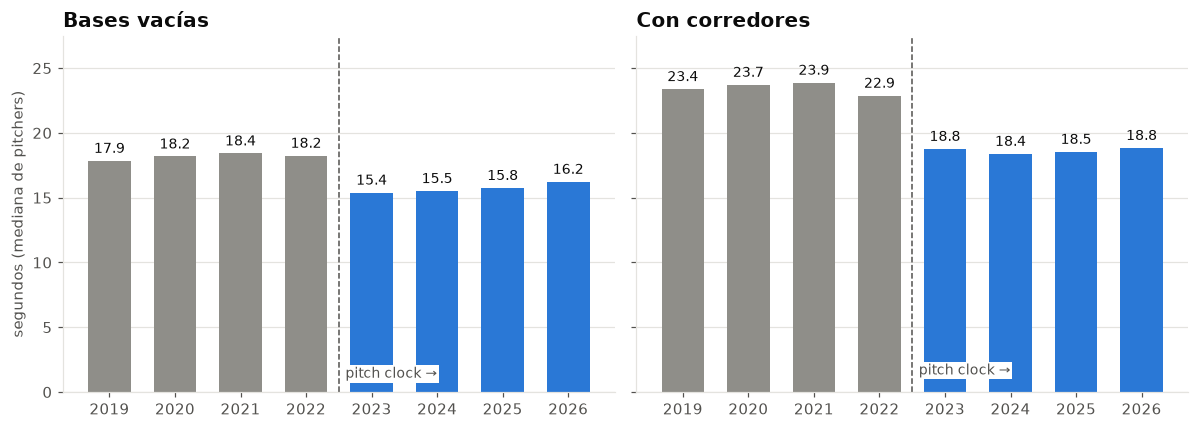

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in zip(axes, ['median_tempo_empty_sec', 'median_tempo_runners_sec'],
                          ['Bases vacías', 'Con corredores']):
    year_bars(ax, lg.set_index('season')[col], fmt='{:.1f}', exclude=())
    ax.set_title(title); clock_line(ax)
axes[0].set_ylabel('segundos (mediana de pitchers)')
plt.tight_layout(); plt.show()

## 2. Spin rate

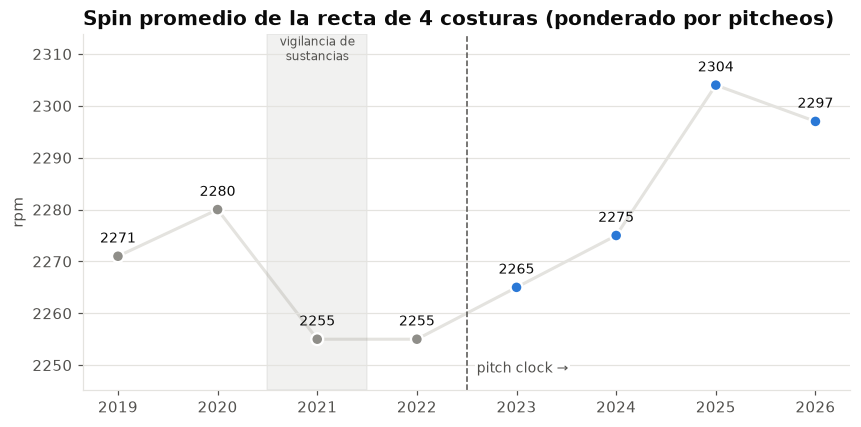

In [5]:
fig, ax = plt.subplots()
year_points(ax, lg.set_index('season')['pitch_weighted_spin_FF'])
ax.set_ylabel('rpm')
ax.set_title('Spin promedio de la recta de 4 costuras (ponderado por pitcheos)')
ax.axvspan(2020.5, 2021.5, color=PRE, alpha=.12)
ax.text(2021, ax.get_ylim()[1], 'vigilancia de\nsustancias', ha='center', va='top', fontsize=8, color=MUTED)
clock_line(ax); plt.show()

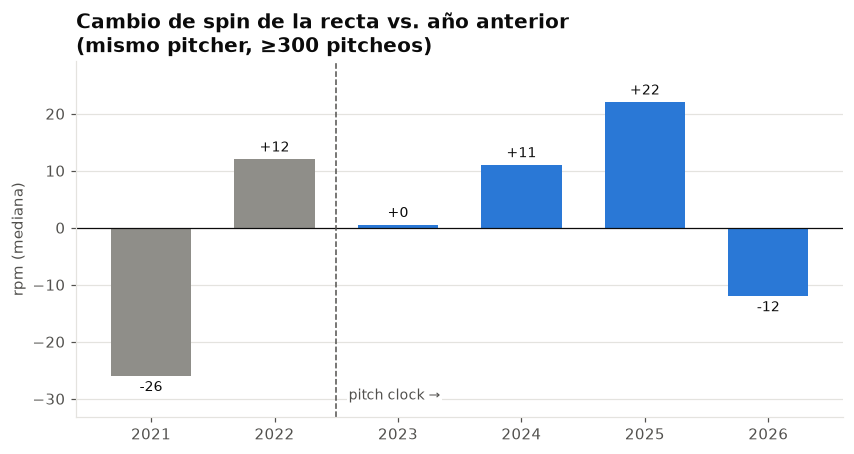

,n,mediana_delta,pct_baja_50rpm
season,,,
2020,281,-2.0,0.288
2021,417,-26.0,0.343
2022,436,12.0,0.177
2023,426,0.5,0.171
2024,419,11.0,0.169
2025,419,22.0,0.084
2026,425,-12.0,0.207


In [6]:
# Cambio año contra año del mismo pitcher (recta). Mismo pitcher = controla composición.
d = ps.dropna(subset=['spin_FF_delta'])
d = d[d.pitches >= 300]
fig, ax = plt.subplots()
year_bars(ax, d.groupby('season')['spin_FF_delta'].median(), fmt='{:+.0f}', exclude=(2020,))
ax.axhline(0, color=INK, lw=0.8)
ax.set_ylabel('rpm (mediana)'); ax.set_title('Cambio de spin de la recta vs. año anterior\n(mismo pitcher, ≥300 pitcheos)')
clock_line(ax); plt.show()
d.groupby('season').agg(n=('pitcher_id', 'size'), mediana_delta=('spin_FF_delta', 'median'),
                        pct_baja_50rpm=('spin_drop_flag', 'mean')).round(3)

In [7]:
# Spin por tipo de pitcheo, 2022 (último año sin reloj) vs. 2023
types = ['FF', 'SI', 'FC', 'SL', 'ST', 'CU', 'CH']
rows = []
for t in types:
    sub = ps[ps.pitches >= 300]
    rows.append({'tipo': t, **{y: sub.loc[sub.season == y, f'spin_{t}'].median() for y in (2022, 2023, 2026)}})
spin_types = pd.DataFrame(rows).set_index('tipo')
spin_types['Δ 2022→23'] = spin_types[2023] - spin_types[2022]
spin_types.round(0)

,2022,2023,2026,Δ 2022→23
tipo,,,,
FF,2259.0,2262.0,2300.0,4.0
SI,2151.0,2165.0,2220.0,14.0
FC,2356.0,2354.0,2372.0,-2.0
SL,2384.0,2385.0,2423.0,1.0
ST,2507.0,2514.0,2583.0,7.0
CU,2464.0,2473.0,2553.0,9.0
CH,1720.0,1730.0,1695.0,10.0


## 3. Lesiones de pitchers
Las estancias COVID se excluyen. En 2020 la temporada fue de 60 juegos, así que se muestra pero no se compara.

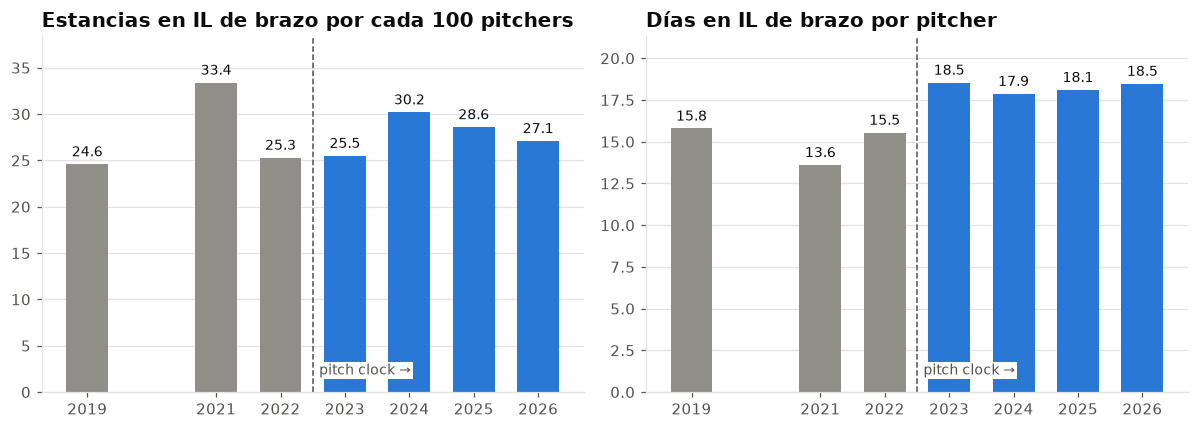

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
year_bars(axes[0], lg.set_index('season')['arm_il_stints_per_100_pitchers'], fmt='{:.1f}')
axes[0].set_title('Estancias en IL de brazo por cada 100 pitchers'); clock_line(axes[0])
lg_ = lg.set_index('season')
year_bars(axes[1], (lg_['arm_il_days'] / lg_['pitchers_used']), fmt='{:.1f}')
axes[1].set_title('Días en IL de brazo por pitcher'); clock_line(axes[1])
plt.tight_layout(); plt.show()

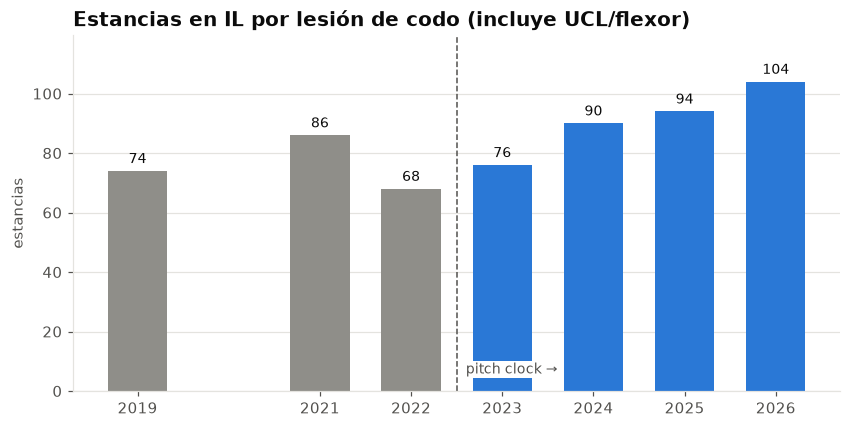

,season,il_stints,arm_il_stints,elbow_il_stints,serious_arm_injuries,ucl_injuries,tommy_john
0,2019,350,191,74,79,11,4
1,2020,220,113,39,49,3,0
2,2021,703,284,86,88,5,0
3,2022,476,204,68,71,5,2
4,2023,396,205,76,96,4,2
5,2024,430,242,90,85,7,2
6,2025,406,230,94,99,11,3
7,2026,393,220,104,93,8,1


In [9]:
fig, ax = plt.subplots()
year_bars(ax, lg.set_index('season')['elbow_il_stints'])
ax.set_title('Estancias en IL por lesión de codo (incluye UCL/flexor)'); ax.set_ylabel('estancias')
clock_line(ax); plt.show()
lg[['season', 'il_stints', 'arm_il_stints', 'elbow_il_stints', 'serious_arm_injuries', 'ucl_injuries', 'tommy_john']]

In [10]:
# Comparación por bloque y rol (excluye 2020)
blk = ps[ps.season != 2020].assign(periodo=lambda x: np.where(x.post_clock == 1, '2023–26 con reloj', '2019,21–22 sin reloj'))
(blk.groupby(['role', 'periodo'])
    .agg(pitchers=('pitcher_id', 'size'), arm_il_rate=('arm_il_stints', lambda s: (s > 0).mean()),
         serious_arm=('serious_arm_injury', 'mean'), arm_il_days=('arm_il_days', 'mean'),
         tempo_empty=('tempo_empty_sec', 'median'), spin_FF=('spin_FF', 'median'), velo_FF=('velo_FF', 'median'))
    .round(3))

pitchers  arm_il_rate  serious_arm  arm_il_days  \
role periodo                                                                 
RP   2019,21–22 sin reloj      1682        0.197        0.091       13.430   
     2023–26 con reloj         2231        0.203        0.093       15.193   
SP   2019,21–22 sin reloj       750        0.263        0.113       18.349   
     2023–26 con reloj          990        0.311        0.168       25.139   

                           tempo_empty  spin_FF  velo_FF  
role periodo                                              
RP   2019,21–22 sin reloj       18.945   2264.0     93.9  
     2023–26 con reloj          15.984   2294.0     94.5  
SP   2019,21–22 sin reloj       16.850   2232.5     93.0  
     2023–26 con reloj          15.204   2273.0     93.7

## 4. ¿Los pitchers que más tuvieron que acelerar sufrieron más?

Diferencias en diferencias informal: pitchers con tempo en **2022 y 2023**. Se dividen según cuánto bajó su tempo con bases vacías (cuartil más acelerado vs. el resto) y se compara su spin y sus lesiones en 2023.

In [11]:
a = ps[ps.season == 2022].set_index('pitcher_id')
b = ps[ps.season == 2023].set_index('pitcher_id')
both = a[['tempo_empty_sec', 'spin_FF', 'velo_FF']].join(
    b[['tempo_empty_sec', 'spin_FF', 'velo_FF', 'arm_il_stints', 'serious_arm_injury', 'pitches']],
    lsuffix='_22', rsuffix='_23', how='inner').dropna(subset=['tempo_empty_sec_22', 'tempo_empty_sec_23'])
both['tempo_change'] = both.tempo_empty_sec_23 - both.tempo_empty_sec_22
both['spin_change'] = both.spin_FF_23 - both.spin_FF_22
both['velo_change'] = both.velo_FF_23 - both.velo_FF_22
q = both.tempo_change.quantile(.25)
both['grupo'] = np.where(both.tempo_change <= q, 'más aceleraron (Q1)', 'resto')
print(f'n={len(both)}; corte Q1 = {q:.1f} s')
display(both.groupby('grupo').agg(n=('tempo_change', 'size'), tempo_change=('tempo_change', 'median'),
                                  spin_change=('spin_change', 'median'), velo_change=('velo_change', 'median'),
                                  arm_il_2023=('arm_il_stints', lambda s: (s > 0).mean()),
                                  serious_arm_2023=('serious_arm_injury', 'mean')).round(3))
both[['tempo_change', 'spin_change', 'velo_change', 'arm_il_stints']].corr(method='spearman').round(3)

n=511; corte Q1 = -4.1 s


,n,tempo_change,spin_change,velo_change,arm_il_2023,serious_arm_2023
grupo,,,,,,
más aceleraron (Q1),128,-5.096,-2.0,-0.3,0.258,0.094
resto,383,-2.328,-0.5,-0.2,0.248,0.141


,tempo_change,spin_change,velo_change,arm_il_stints
tempo_change,1.000,0.028,0.158,-0.007
spin_change,0.028,1.000,0.296,-0.060
velo_change,0.158,0.296,1.000,-0.062
arm_il_stints,-0.007,-0.060,-0.062,1.000


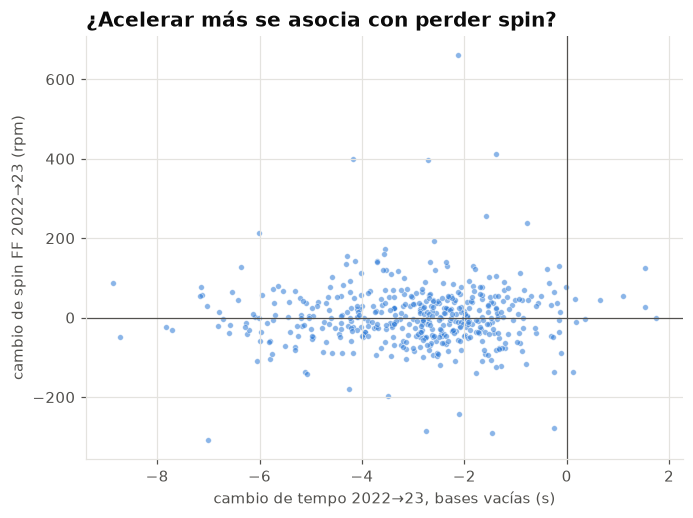

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
m = both.dropna(subset=['spin_change'])
ax.scatter(m.tempo_change, m.spin_change, s=14, color=POST, alpha=.55, edgecolor='white', linewidth=.5)
ax.axhline(0, color=MUTED, lw=.8); ax.axvline(0, color=MUTED, lw=.8)
ax.set_xlabel('cambio de tempo 2022→23, bases vacías (s)'); ax.set_ylabel('cambio de spin FF 2022→23 (rpm)')
ax.set_title('¿Acelerar más se asocia con perder spin?'); ax.grid(axis='x', color=GRID)
plt.show()

## Conclusiones

- **Tiempo**: efecto inmediato y persistente. Los juegos de 9 entradas pasaron de 184 a 160 min (2022→2023) y siguen en 156–162 hasta 2026. El tempo mediano bajó ~3 s con bases vacías y ~4 s con corredores.
- **Spin**: **no se ve una bajada** atribuible al reloj. El spin de la recta sube desde 2022, y la única caída clara fue la de 2021 (sustancias pegajosas). El cambio de tempo de cada pitcher no se correlaciona con su cambio de spin (Spearman ≈ 0,03).
- **Lesiones**: más días en IL de brazo por pitcher (15,5 → ~18) y más estancias por codo cada año. En abridores, la tasa de lesión grave de brazo pasó de 11,3% a 16,8%. Es una asociación, no una causa: la velocidad también sigue subiendo.